In [1]:
import sys
sys.path.append("/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/")

import numpy as np
import os 
import sys
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import concurrent
import concurrent.futures
from astropy.visualization import ImageNormalize, AsinhStretch
from juanfit import gaussian
import importlib
from plotting_modules import doppler_plot, amplitude_plot

In [2]:
spice_file = "~/work/spice_psf/spice_data/solo_L2_spice-n-ras_20231031T141032_V22_218104216-000.fits"

with fits.open(spice_file) as hdul:
    # hdul.info()
    spice_NeVIII_data = hdul[1].data[0].copy()
    spice_NeVIII_header = hdul[1].header.copy()
spice_NeVIII_data = spice_NeVIII_data.T
# spice_NeVIII_header["NAXIS1"] = 60
# spice_NeVIII_header["NAXIS2"] = 240
# spice_NeVIII_data = spice_NeVIII_data[30:90,240:480,:]

In [3]:
spice_NeVIII_data.shape

(192, 836, 25)

In [5]:
import skew_correction
from skew_correction import full_correction
importlib.reload(skew_correction)
from skew_correction import full_correction

best_skew_x, best_skew_y = 2.333, -3.667

best_correction_results = full_correction(spice_NeVIII_data, spice_NeVIII_header, best_skew_x, best_skew_y, nthreads=12,
                                          spice_sdev_guess=0.1, linelist={'Ne VIII 770':770.4})

/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:92: RuntimeWarning: All-NaN slice encountered
  spice_dat = copy.deepcopy(spice_dat_in) - np.nanmean(np.nanmin(spice_dat_in,axis=0))
/cluster/home/zhuyin/scripts/spice-line-fits/linefit_modules/util.py:94: RuntimeWarning: Mean of empty slice
  signal = np.nanmean(signal_cube,axis=(0,2))


0 [False]
1 [False]
2 [False]
3 [False]
4 [False]
5 [False]
6 [False]
7 [False]
8 [False]
9 [False]
10 [False]
11 [False]
12 [False]
13 [False]
14 [False]
15 [False]
16 [False]
17 [False]
18 [False]
19 [False]
20 [False]
21 [False]
22 [False]
23 [False]
24 [False]
25 [False]
26 [False]
27 [False]
28 [False]
29 [False]
30 [False]
31 [False]
32 [False]
33 [False]
34 [False]
35 [False]
36 [False]
37 [False]
38 [False]
39 [False]
40 [False]
41 [False]
42 [False]
43 [False]
44 [False]
45 [False]
46 [False]
47 [False]
48 [False]
49 [False]
50 [False]
51 [False]
52 [False]
53 [False]
54 [False]
55 [False]
56 [False]
57 [False]
58 [False]
59 [False]
60 [False]
61 [False]
62 [False]
63 [False]
64 [False]
65 [False]
66 [False]
67 [False]
68 [False]
69 [False]
70 [False]
71 [False]
72 [False]
73 [False]
74 [False]
75 [False]
76 [False]
77 [False]
78 [False]
79 [False]
80 [False]
81 [False]
82 [False]
83 [False]
84 [False]
85 [False]
86 [False]
87 [False]
88 [False]
89 [False]
90 [False]
91 [False

In [7]:
def correction_preview(best_correction_results):
    plt_linefits = best_correction_results['linefits']
    ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
    line_name = list(plt_linefits[0].keys())[0]
    date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

    fig=plt.figure(figsize=[16,8])
    gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
    cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
    axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

    plt.suptitle('Corrected fits for '+line_name+' at '+date)
    amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
    doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
    axes[1].set(title='Doppler; best xshift, yshift='+str(best_correction_results['xlshift'])+','+str(best_correction_results['ylshift']))

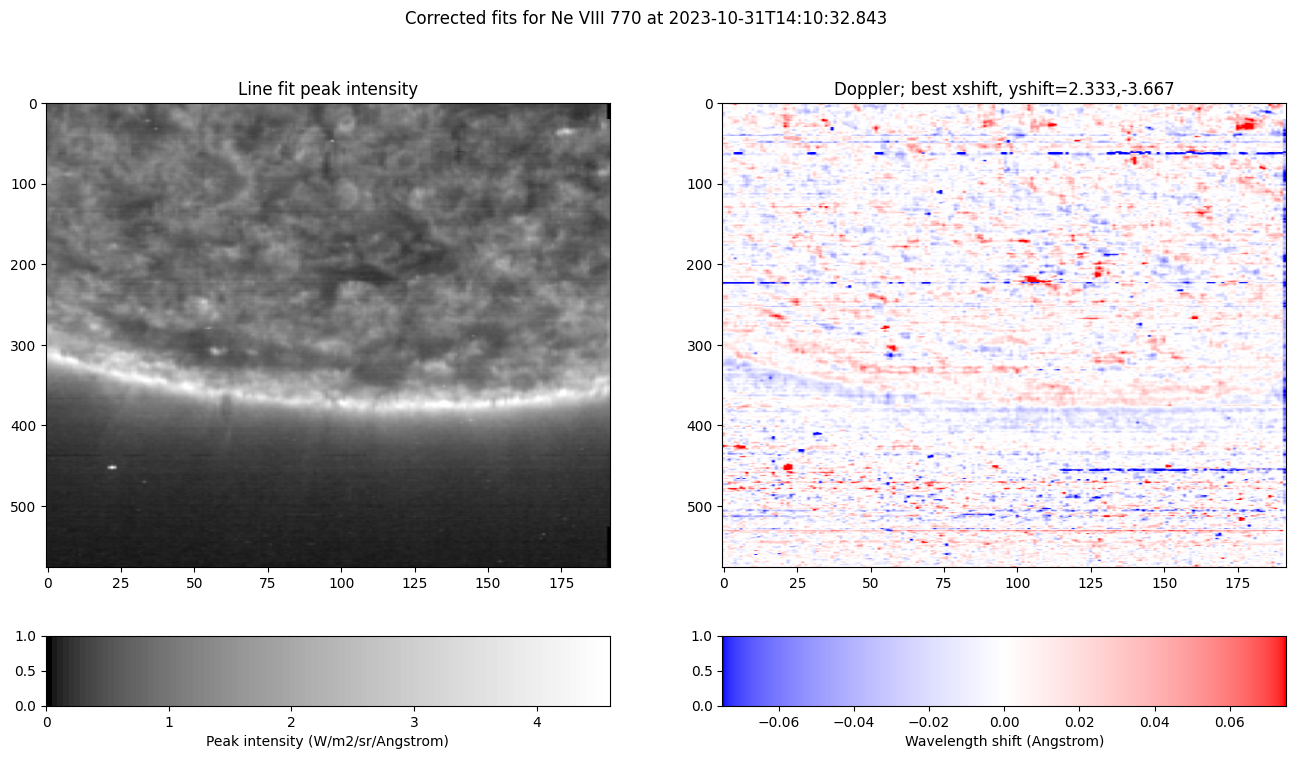

In [8]:
correction_preview(best_correction_results)

In [5]:
def func_NeVIII_770_sg(x, wvl_770, int_770, wid_770, b):
    return gaussian(x, wvl_770, int_770, wid_770) + \
           b

In [51]:
def work_fit_single_spec(args):
    (NeVIII_770_wvl, NeVIII_770_data_rebin,
    NeVIII_770_window_start, NeVIII_window_end,
    ii, jj) = args
    
    try:
        data_slice = NeVIII_770_data_rebin[NeVIII_770_window_start[ii,jj]:NeVIII_window_end[ii,jj]+1,
                                           ii, jj]
        
        p0 = [
            NeVIII_770_wvl[np.nanargmax(data_slice)],  # wavelength of max
            np.nanmax(data_slice),  # intensity 
            0.8,  # width
            0   # background
        ]
        
        # Bounds for parameters
        bounds = (
            (0, 0, 0, -np.inf),
            (np.inf, np.inf, np.inf, np.inf)
        )
        
        # Perform curve fitting
        popt, pcov = curve_fit(
            func_NeVIII_770_sg,
            NeVIII_770_wvl[NeVIII_770_window_start[ii,jj]:NeVIII_window_end[ii,jj]+1],
            data_slice,
            p0=p0,
            bounds=bounds,
            nan_policy="omit"
        )

        perr = np.sqrt(np.diag(pcov))

        if np.any(~np.isfinite(popt)) or np.any(~np.isfinite(perr)) \
            or np.any(np.abs(perr[:3]/popt[:3]) > 0.3):
            return (ii, jj, None)
        else:
            return (ii, jj, popt)
    
    except:
        # Return None or a special marker for failed fits
        return (ii, jj, None)


In [44]:
def fit_parallel(NeVIII_770_wvl, NeVIII_770_data_rebin, NeVIII_770_window_start=None,
                 NeVIII_770_window_end=None, ncpu=8):
    # Prepare input arguments for each position
    input_args = [
        (NeVIII_770_wvl, NeVIII_770_data_rebin,
         NeVIII_770_window_start, NeVIII_770_window_end,
         ii, jj) 
        for ii in range(NeVIII_770_data_rebin.shape[1]) 
        for jj in range(NeVIII_770_data_rebin.shape[2])
    ]
    
    # Prepare result arrays
    shape = NeVIII_770_data_rebin.shape[1:]
    NeVIII_fit_wvl = np.ones(shape)*np.nan
    NeVIII_fit_int = np.ones(shape)*np.nan
    NeVIII_fit_wid = np.ones(shape)*np.nan
    NeVIII_fit_b = np.ones(shape)*np.nan
    
    # Use ProcessPoolExecutor to parallelize fitting
    with ProcessPoolExecutor(max_workers=ncpu) as executor:
        # Submit all tasks
        futures = [executor.submit(work_fit_single_spec, args) for args in input_args]
        
        # Process results as they complete
        for future in concurrent.futures.as_completed(futures):
            result = future.result()
            
            # Check if fitting was successful
            if result[2] is not None:
                ii, jj, popt = result
                
                # Store results in respective arrays
                NeVIII_fit_wvl[ii, jj] = popt[0]
                NeVIII_fit_int[ii, jj] = popt[1]
                NeVIII_fit_wid[ii, jj] = popt[2]
                NeVIII_fit_b[ii, jj] = popt[3]
    
    return (
        NeVIII_fit_wvl, 
        NeVIII_fit_int, 
        NeVIII_fit_wid, 
        NeVIII_fit_b
    )

In [25]:
best_correction_results.keys()

dict_keys(['dat_skew', 'err_skew', 'linefits', 'xlshift', 'ylshift', 'kwargs', 'hdr', 'centers', 'lines', 'mask', 'waves', 'offsets', 'ymin', 'ymax'])

In [56]:
dat_skew_rebin = best_correction_results['dat_skew'].T
dat_skew_rebin = dat_skew_rebin[:,120:-120,:]
dat_skew_rebin = np.nanmean(dat_skew_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)

/scratch/tmp.29353421.zhuyin/ipykernel_83327/1000474420.py:3: RuntimeWarning: Mean of empty slice
  dat_skew_rebin = np.nanmean(dat_skew_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)


In [57]:
dat_skew_rebin.shape

(25, 298, 192)

In [58]:
(NeVIII_skew_fit_wvl_r1, NeVIII_skew_fit_int_r1, NeVIII_skew_fit_wid_r1,
NeVIII_skew_fit_b_r1) = fit_parallel(best_correction_results['waves'],
                                     dat_skew_rebin,
                                     0*np.ones(dat_skew_rebin.shape[1:], dtype=int),
                                     24*np.ones(dat_skew_rebin.shape[1:], dtype=int))

In [60]:
dat_raw_rebin = spice_NeVIII_data.T
dat_raw_rebin = dat_raw_rebin[:,120:-120,:]
dat_raw_rebin = np.nanmean(dat_raw_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)

/scratch/tmp.29353421.zhuyin/ipykernel_83327/2019165435.py:3: RuntimeWarning: Mean of empty slice
  dat_raw_rebin = np.nanmean(dat_raw_rebin.reshape(25, (836-240)//2, 2, 192), axis=2)


In [61]:
(NeVIII_raw_fit_wvl_r1, NeVIII_raw_fit_int_r1, NeVIII_raw_fit_wid_r1,
NeVIII_raw_fit_b_r1) = fit_parallel(best_correction_results['waves'],
                                     dat_raw_rebin,
                                     0*np.ones(dat_raw_rebin.shape[1:], dtype=int),
                                     24*np.ones(dat_raw_rebin.shape[1:], dtype=int))

In [64]:
plot_aspect = best_correction_results['hdr']['CDELT2']/best_correction_results['hdr']['CDELT1']*2

Text(0, 0.5, 'Raw')

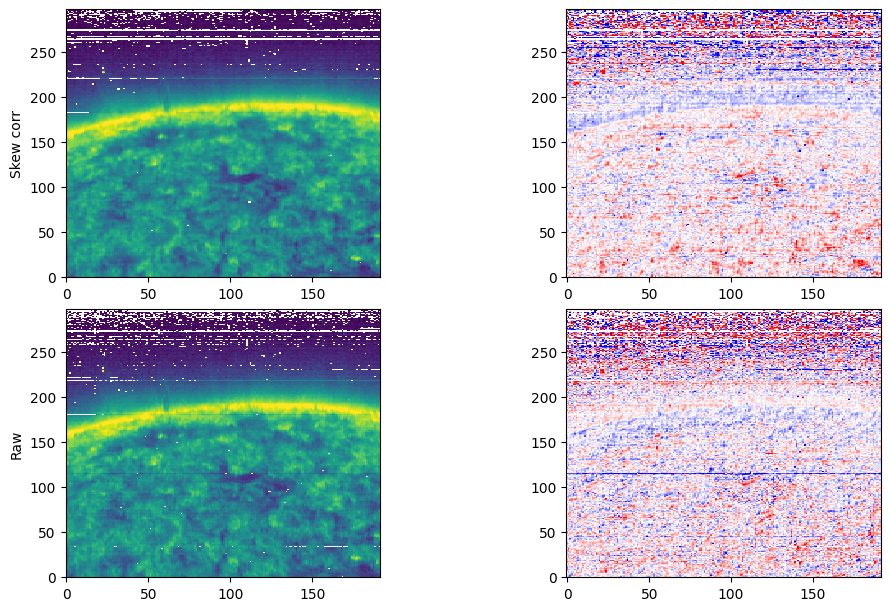

In [67]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(10,6), layout="constrained")

ax1.imshow(NeVIII_skew_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_skew_fit_int_r1, 0.5),
                                vmax=np.nanpercentile(NeVIII_skew_fit_int_r1, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax2.imshow((NeVIII_skew_fit_wvl_r1 - np.nanmedian(NeVIII_skew_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax3.imshow(NeVIII_raw_fit_int_r1, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_raw_fit_int_r1, 0.5),
                                vmax=np.nanpercentile(NeVIII_raw_fit_int_r1, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect, interpolation='none')

ax4.imshow((NeVIII_raw_fit_wvl_r1 - np.nanmedian(NeVIII_raw_fit_wvl_r1, axis=0)[np.newaxis,:])/770*3e5,
            norm=ImageNormalize(vmin=-40, vmax=40), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax1.set_ylabel("Skew corr")
ax3.set_ylabel("Raw")


[Text(0.5, 1.0, 'Doppler; best xshift, yshift=2.333,-3.667')]

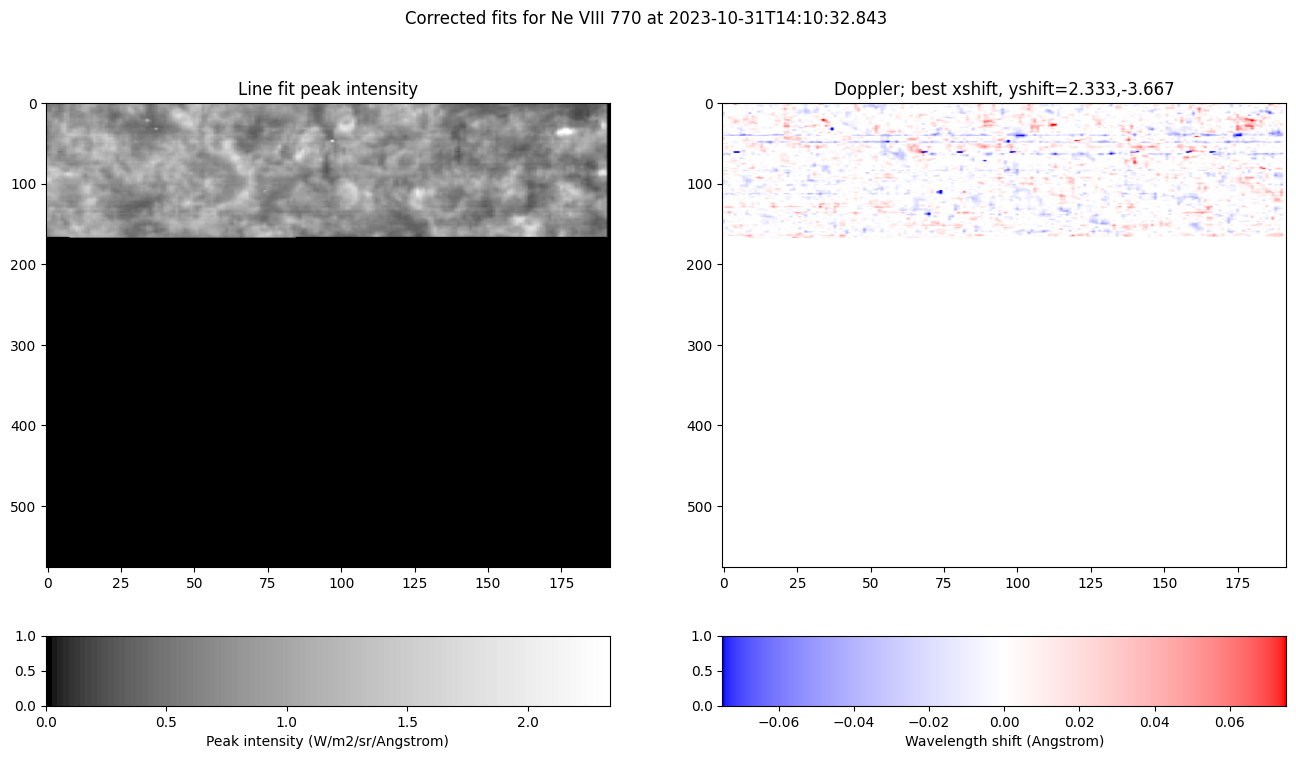

In [13]:
from plotting_modules import doppler_plot, amplitude_plot

plt_linefits = best_correction_results['linefits']
ymin,ymax = best_correction_results['ymin'],best_correction_results['ymax']
line_name = list(plt_linefits[0].keys())[0]
date = plt_linefits[0][0]['amplitudes'].meta['DATE-OBS']

fig=plt.figure(figsize=[16,8])
gs = fig.add_gridspec(nrows=2,ncols=2,width_ratios=[1,1],height_ratios=[7,1])
cbaxes = [fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1])]
axes = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])]

plt.suptitle('Corrected fits for '+line_name+' at '+date)
amplitude_plot(plt_linefits[0][0],axis=axes[0], cbaxis=cbaxes[0], ymin=ymin, ymax=ymax)
doppler_plot(plt_linefits[0][0],axis=axes[1], cbaxis=cbaxes[1], doppmin=-0.075, doppmax=0.075, ymin=ymin,ymax=ymax)
axes[1].set(title='Doppler; best xshift, yshift='+str(best_skew_x)+','+str(best_skew_y))